# Verification of `car_cd3zeta_phosphorylation_rohrs2018`

Rohrs JA, Zheng D, Graham NA, Wang P, Finley SD (2018). *Computational model of
chimeric antigen receptors explains site-specific phosphorylation kinetics.*
Biophys J **115**(7):1116-1129. [doi:10.1016/j.bpj.2018.08.018](https://doi.org/10.1016/j.bpj.2018.08.018)

The notebook verifies the collection at two levels, as `skills/curate-model`
requires.

**Model-specification verification.** Every BNGL file is compared against an
independent Python/SciPy transcription of the paper's own equations — Eq. 2
(Michaelis-Menten), Eq. 3 (phosphate priming), Eqs. 4 and 5 (competitive
inhibition) and the phosphatase equations of Data S6 — written over the six
ITAM site densities rather than over BioNetGen's generated network. For the
priming mechanism, where the sites are genuinely coupled through the phosphate
count, the independent solution is a master equation over the 64 phosphoforms
enumerated as bit masks in Python. Two structural identities are checked as
well: per-site conservation, and the statistical independence of the six sites
that makes the authors' six-independent-molecule representation of Data S2, S4
and S5 equivalent to the single-chain representation used here.

**Reported-data verification.** The BioNetGen output is compared against data
digitized from the published figures by `digitize_rohrs2018.py` and committed
under `reference/`:

| figure | what is compared | kind |
|---|---|---|
| Fig. S5, A-J | the authors' plotted competitive inhibition curves, and the measured percent phosphorylation with SD | vector |
| Fig. 3, middle and bottom | half-maximal time and Hill coefficient of all four mechanisms | raster |
| Fig. 5A | wild-type response to the phosphatase scan | raster |
| Fig. 5, B and C | normalized log(EC50) and Hill coefficient of seven ITAM configurations | raster |

In [1]:
import json
import re
import shutil
import subprocess
import sys
import tempfile
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

HERE = Path.cwd()
REF = HERE / "reference"
assert REF.is_dir(), f"run this notebook from the model folder; {REF} not found"
SITES = ["A1", "A2", "B1", "B2", "C1", "C2"]


def find_bngpath():
    local = Path.home() / "Simulations" / "BioNetGen-2.9.3"
    if (local / "BNG2.pl").exists():
        return local
    found = shutil.which("BNG2.pl")
    if found:
        return Path(found).parent
    raise FileNotFoundError("BNG2.pl not found; set it up or add it to PATH")


BNGPATH = find_bngpath()
print("BioNetGen:", (BNGPATH / "VERSION").read_text().strip(), "at", BNGPATH)

BioNetGen: 2.9.3 at /Users/l119605/Simulations/BioNetGen-2.9.3


## 1. Run every BNGL file

In [2]:
WORK = Path(tempfile.mkdtemp(prefix="rohrs2018_"))
MODELS = sorted(p.name for p in HERE.glob("car_cd3zeta_phosphorylation_rohrs2018*.bngl"))
for name in MODELS:
    shutil.copy(HERE / name, WORK / name)
    r = subprocess.run([str(BNGPATH / "BNG2.pl"), name], cwd=WORK,
                       capture_output=True, text=True,
                       env={"BNGPATH": str(BNGPATH), "PATH": "/usr/bin:/bin:/usr/sbin:/sbin"})
    assert r.returncode == 0 and "ABORT" not in r.stdout, r.stdout[-3000:]
    print(f"{name:60s} ok")


def read_table(path):
    """Read a BioNetGen .gdat or .scan file into a DataFrame."""
    with open(path) as fh:
        cols = fh.readline().lstrip("#").split()
    return pd.DataFrame(np.loadtxt(path), columns=cols)


def net_size(path):
    text = Path(path).read_text()
    n_sp = len(text.split("begin species")[1].split("end species")[0].strip().splitlines())
    n_rx = len(text.split("begin reactions")[1].split("end reactions")[0].strip().splitlines())
    return n_sp, n_rx


for name in MODELS:
    stem = name[:-5]
    print(f"{stem:60s} {net_size(WORK / (stem + '.net'))[0]:4d} species, "
          f"{net_size(WORK / (stem + '.net'))[1]:4d} reactions")

car_cd3zeta_phosphorylation_rohrs2018.bngl                   ok


car_cd3zeta_phosphorylation_rohrs2018_mutants.bngl           ok


car_cd3zeta_phosphorylation_rohrs2018_phosphatase.bngl       ok


car_cd3zeta_phosphorylation_rohrs2018_priming.bngl           ok


car_cd3zeta_phosphorylation_rohrs2018_random.bngl            ok
car_cd3zeta_phosphorylation_rohrs2018_sequential.bngl        ok
car_cd3zeta_phosphorylation_rohrs2018                          65 species,  192 reactions
car_cd3zeta_phosphorylation_rohrs2018_mutants                 257 species,  672 reactions
car_cd3zeta_phosphorylation_rohrs2018_phosphatase             126 species,  600 reactions
car_cd3zeta_phosphorylation_rohrs2018_priming                  65 species,  192 reactions
car_cd3zeta_phosphorylation_rohrs2018_random                   65 species,  192 reactions
car_cd3zeta_phosphorylation_rohrs2018_sequential                8 species,    6 reactions


### Committed reference output is reproduced

`skills/curate-model/SKILL.md` asks that re-running the model reproduce the
committed `reference/` data: relative error <= 1e-3, or absolute error <=
1e-6 * max|column|.

In [3]:
def matches_reference(a, b):
    bad = 0
    for col in a.columns:
        x, y = a[col].to_numpy(float), b[col].to_numpy(float)
        atol = 1e-6 * np.abs(y).max()
        ok = np.isclose(x, y, rtol=1e-3, atol=max(atol, 1e-300))
        bad += int((~ok).sum())
    return bad


total_bad = 0
checked = 0
for path in sorted(REF.glob("*.gdat")) + sorted(REF.glob("*.scan")):
    fresh = WORK / path.name
    if not fresh.exists():
        continue
    total_bad += matches_reference(read_table(fresh), read_table(path))
    checked += 1
print(f"{checked} committed .gdat/.scan files re-checked, {total_bad} values outside tolerance")
assert total_bad == 0

17 committed .gdat/.scan files re-checked, 0 values outside tolerance

## 2. Model-specification verification

### 2.1 The paper's equations, transcribed independently

All amounts below are surface densities in molecules/um^2, the units of the
paper. The BNGL files carry molecule counts on a patch of area `A_sim`, which
is 1 um^2 at the committed parameterization, so the two coincide numerically.

In [4]:
KM_COMP = dict(A1=96.548, A2=331.68, B1=270.0, B2=153.82, C1=484.9, C2=405.43)
XI = 0.1153
KM_RANDOM = dict(A1=22292.0, A2=1.76e5, B1=1.27e5, B2=57482.0, C1=2.70e5, C2=2.42e5)
KM_SEQ = dict(A1=1.50e5, A2=27000.0, B1=6.03e5, B2=27000.0, C1=8.64e5, C2=27000.0)
KM_PRIME = dict(A1=1.60e5, A2=5.55e6, B1=4.05e6, B2=3.88e5, C1=2.55e8, C2=6.86e6)
PM = dict(A1=10.56, A2=36.3, B1=32.4, B2=18.36, C1=67.2, C2=56.7)
PXI = 0.1
CD3Z_T = 20000.0
SEQ_ORDER = ["A1", "B2", "B1", "A2", "C2", "C1"]


def solve_competitive(t_eval, lck=19.703, kcat=360.0, total=CD3Z_T, dead=(),
                      phos=0.0, pcat=360.0):
    """Eqs. 4 and 5, optionally with the Data S6 phosphatase terms.

    State is pY_i, the phosphorylated density at each live site. A site named in
    `dead` is a tyrosine-to-phenylalanine mutation: it is neither a substrate nor
    a competitor, so it simply drops out of both sums.
    """
    live = [s for s in SITES if s not in dead]

    def rhs(_, py):
        py = dict(zip(live, py))
        y = {s: total - py[s] for s in live}
        dk = 1.0 + sum(y[s] / KM_COMP[s] + py[s] / (KM_COMP[s] * XI) for s in live)
        dp = 1.0 + sum(py[s] / PM[s] + y[s] / (PM[s] * PXI) for s in live)
        return [kcat / KM_COMP[s] * y[s] * lck / dk
                - (pcat / PM[s] * py[s] * phos / dp if phos else 0.0) for s in live]

    sol = solve_ivp(rhs, (0.0, t_eval[-1]), np.zeros(len(live)), t_eval=t_eval,
                    method="LSODA", rtol=1e-11, atol=1e-9)
    out = {s: np.zeros_like(sol.t) for s in SITES}
    for i, s in enumerate(live):
        out[s] = sol.y[i]
    return out


def solve_random(t_eval, lck=1.0, kcat=1892.4, total=CD3Z_T):
    """Eq. 2, one independent Michaelis-Menten substrate per site."""
    def rhs(_, py):
        return [kcat * lck * (total - py[i]) / (KM_RANDOM[s] + total - py[i])
                for i, s in enumerate(SITES)]

    sol = solve_ivp(rhs, (0.0, t_eval[-1]), np.zeros(6), t_eval=t_eval,
                    method="LSODA", rtol=1e-11, atol=1e-9)
    return dict(zip(SITES, sol.y))


def solve_sequential(t_eval, lck=20.0, kcat=360.0, total=CD3Z_T):
    """Eq. 2 along the fixed chain A1 -> B2 -> B1 -> A2 -> C2 -> C1.

    State k is the density of chains that have completed k steps.
    """
    def rhs(_, x):
        d = np.zeros(7)
        for k, s in enumerate(SEQ_ORDER):
            v = kcat * lck * x[k] / (KM_SEQ[s] + x[k])
            d[k] -= v
            d[k + 1] += v
        return d

    x0 = np.zeros(7)
    x0[0] = total
    sol = solve_ivp(rhs, (0.0, t_eval[-1]), x0, t_eval=t_eval, method="LSODA",
                    rtol=1e-11, atol=1e-9)
    return {s: sol.y[k + 1:].sum(axis=0) for k, s in enumerate(SEQ_ORDER)}


def solve_priming(t_eval, lck=16.491, kcat=381.73, lam=3.0, total=CD3Z_T):
    """Eq. 3 as a master equation over the 64 phosphoforms.

    Bit i of a state index marks site SITES[i] as phosphorylated. The Michaelis
    constant a chain presents at site i is K_M,i / lambda^p with p the number of
    phosphates already on that chain, so the states are coupled and cannot be
    collapsed to six equations.
    """
    n = len(SITES)
    popcount = np.array([bin(m).count("1") for m in range(1 << n)])

    def rhs(_, x):
        y = np.array([x[[m for m in range(1 << n) if not (m >> i) & 1]].sum()
                      for i in range(n)])
        d = np.zeros_like(x)
        for m in range(1 << n):
            if x[m] == 0.0 and m != 0:
                pass
            p = popcount[m]
            for i, s in enumerate(SITES):
                if (m >> i) & 1:
                    continue
                km = KM_PRIME[s] / lam ** p
                v = kcat * lck * x[m] / (km + y[i])
                d[m] -= v
                d[m | (1 << i)] += v
        return d

    x0 = np.zeros(1 << n)
    x0[0] = total
    sol = solve_ivp(rhs, (0.0, t_eval[-1]), x0, t_eval=t_eval, method="LSODA",
                    rtol=1e-10, atol=1e-8)
    return {s: sol.y[[m for m in range(1 << n) if (m >> i) & 1]].sum(axis=0)
            for i, s in enumerate(SITES)}

### 2.2 BioNetGen against the independent solutions

In [5]:
def compare(bng, indep, label, tol_pp):
    rows = []
    for s in SITES:
        sim = bng["pct_" + s].to_numpy()
        ref = 100.0 * indep[s] / CD3Z_T
        rows.append(dict(site=s, max_abs_pp=np.abs(sim - ref).max(),
                         max_rel=np.abs(sim - ref).max() / max(sim.max(), 1e-12)))
    df = pd.DataFrame(rows).set_index("site")
    worst = df.max_abs_pp.max()
    print(f"{label:34s} max |BNG - SciPy| = {worst:.3e} percentage points"
          f"   ({'PASS' if worst < tol_pp else 'FAIL'} at {tol_pp} pp)")
    assert worst < tol_pp
    return df


spec_tables = {}
g = read_table(WORK / "car_cd3zeta_phosphorylation_rohrs2018_ode.gdat")
spec_tables["competitive inhibition"] = compare(
    g, solve_competitive(g.time.to_numpy()), "competitive inhibition (Eqs. 4, 5)", 1e-4)

g_seq = read_table(WORK / "car_cd3zeta_phosphorylation_rohrs2018_sequential_ode.gdat")
spec_tables["sequential order"] = compare(
    g_seq, solve_sequential(g_seq.time.to_numpy()), "sequential order (Eq. 2)", 1e-4)

g_rnd = read_table(WORK / "car_cd3zeta_phosphorylation_rohrs2018_random_ode.gdat")
spec_tables["random order"] = compare(
    g_rnd, solve_random(g_rnd.time.to_numpy()), "random order (Eq. 2)", 1e-4)

g_prm = read_table(WORK / "car_cd3zeta_phosphorylation_rohrs2018_priming_ode.gdat")
spec_tables["phosphate priming"] = compare(
    g_prm, solve_priming(g_prm.time.to_numpy()), "phosphate priming (Eq. 3)", 1e-3)

competitive inhibition (Eqs. 4, 5) max |BNG - SciPy| = 1.284e-06 percentage points   (PASS at 0.0001 pp)
sequential order (Eq. 2)           max |BNG - SciPy| = 3.164e-07 percentage points   (PASS at 0.0001 pp)
random order (Eq. 2)               max |BNG - SciPy| = 4.253e-08 percentage points   (PASS at 0.0001 pp)


phosphate priming (Eq. 3)          max |BNG - SciPy| = 2.751e-07 percentage points   (PASS at 0.001 pp)


In [6]:
MUTANTS = {"A1F": "A1", "A2F": "A2", "B1F": "B1", "B2F": "B2", "C1F": "C1", "C2F": "C2"}
worst_mutant = 0.0
for tag, site in MUTANTS.items():
    gm = read_table(WORK / f"car_cd3zeta_phosphorylation_rohrs2018_mutants_ode_{tag}.gdat")
    indep = solve_competitive(gm.time.to_numpy(), dead=(site,))
    err = max(np.abs(gm["pct_" + s].to_numpy() - 100 * indep[s] / CD3Z_T).max() for s in SITES)
    worst_mutant = max(worst_mutant, err)
    print(f"  {tag} mutant: max |BNG - SciPy| = {err:.3e} pp")
print(f"\nsix Y->F mutants                   max |BNG - SciPy| = {worst_mutant:.3e} pp")
assert worst_mutant < 1e-4

  A1F mutant: max |BNG - SciPy| = 2.569e-06 pp
  A2F mutant: max |BNG - SciPy| = 3.127e-06 pp
  B1F mutant: max |BNG - SciPy| = 3.239e-06 pp
  B2F mutant: max |BNG - SciPy| = 3.599e-06 pp
  C1F mutant: max |BNG - SciPy| = 2.945e-06 pp
  C2F mutant: max |BNG - SciPy| = 2.937e-06 pp

six Y->F mutants                   max |BNG - SciPy| = 3.599e-06 pp


In [7]:
# Phosphatase model: check the whole scan, one steady state per phosphatase level.
scan = read_table(WORK / "car_cd3zeta_phosphorylation_rohrs2018_phosphatase_scan_ABC.scan")
err_scan = []
for _, row in scan.iterrows():
    indep = solve_competitive(np.array([0.0, 10.0]), lck=1000.0, total=1.0,
                              phos=row.Phos_T)
    pct = 100.0 * sum(indep[s][-1] for s in SITES) / 6.0
    err_scan.append(abs(pct - row.pct_total))
print(f"phosphatase scan (Data S6 equations) max |BNG - SciPy| = {max(err_scan):.3e} pp "
      f"over {len(err_scan)} phosphatase levels")
assert max(err_scan) < 1e-3

phosphatase scan (Data S6 equations) max |BNG - SciPy| = 2.375e-05 pp over 41 phosphatase levels


### 2.3 Structural identities

**Conservation.** In the three mechanisms whose `Y_i` observable is the whole
unphosphorylated pool at site *i*, every site must satisfy
`Y_i + pY_i = CD3z_T`. The sequential file is the exception by construction:
there `Y_i` counts only the chains that have reached step *i*, so the
conservation law it obeys instead is the chain ordering
`pY_A1 >= pY_B2 >= pY_B1 >= pY_A2 >= pY_C2 >= pY_C1`, with `pY_A1 <= CD3z_T`.

**Independence.** In the competitive inhibition and random-order mechanisms no
rate law depends on the state of a *neighboring* site — only on aggregate
densities — so on a single chain the six sites stay statistically independent
if they start that way, and the doubly phosphorylated ITAM observable must
equal the product of its two site fractions. That is exactly what makes the
authors' representation in Data S2, S4 and S5 — six independent molecule types,
each seeded at the full CD3zeta density — exact for everything they report, and
what licenses the single-chain representation used here. The two mechanisms
that *do* couple sites on the same chain, sequential order and phosphate
priming, must violate it, and the size of the violation is the information the
single-chain representation adds.

In [8]:
for label, tab in [("competitive inhibition", g), ("random order", g_rnd),
                   ("phosphate priming", g_prm)]:
    cons = max(np.abs(tab[f"Y_{s}"] + tab[f"pY_{s}"] - CD3Z_T).max() for s in SITES)
    print(f"{label:24s} max |Y_i + pY_i - CD3z_T| = {cons:.2e} molecules")
    assert cons < 1e-5

chain = np.column_stack([g_seq[f"pY_{s}"].to_numpy() for s in SEQ_ORDER])
print(f"{'sequential order':24s} chain ordering violated at "
      f"{int((np.diff(chain, axis=1) > 1e-6).sum())} of {chain[:, 1:].size} points; "
      f"max pY_A1 = {chain[:, 0].max():.1f} of {CD3Z_T:.0f}")
assert (np.diff(chain, axis=1) <= 1e-6).all() and chain[:, 0].max() <= CD3Z_T + 1e-6

print()
for label, tab, coupled in [("competitive inhibition", g, False),
                            ("random order", g_rnd, False),
                            ("sequential order", g_seq, True),
                            ("phosphate priming", g_prm, True)]:
    prod = max(np.abs(tab[f"ITAM_{itam}_2p"]
                      - tab[f"pY_{itam}1"] * tab[f"pY_{itam}2"] / CD3Z_T).max()
               for itam in "ABC")
    verdict = "coupled, as expected" if coupled else "independent, as expected"
    print(f"{label:24s} max |ITAM_2p - pY*pY/CD3z_T| = {prod:9.2e} molecules  ({verdict})")
    if coupled:
        assert prod > 1.0
    else:
        assert prod < 1e-3

competitive inhibition   max |Y_i + pY_i - CD3z_T| = 3.00e-08 molecules
random order             max |Y_i + pY_i - CD3z_T| = 8.50e-08 molecules
phosphate priming        max |Y_i + pY_i - CD3z_T| = 3.89e-08 molecules
sequential order         chain ordering violated at 0 of 410 points; max pY_A1 = 20000.0 of 20000

competitive inhibition   max |ITAM_2p - pY*pY/CD3z_T| =  1.07e-04 molecules  (independent, as expected)
random order             max |ITAM_2p - pY*pY/CD3z_T| =  5.96e-06 molecules  (independent, as expected)
sequential order         max |ITAM_2p - pY*pY/CD3z_T| =  1.67e+03 molecules  (coupled, as expected)
phosphate priming        max |ITAM_2p - pY*pY/CD3z_T| =  1.34e+03 molecules  (coupled, as expected)


## 3. Reported-data verification

### 3.1 Figure S5: the authors' own competitive inhibition curves

Fig. S5 is vector art, so each plotted vertex is recovered exactly; the only
uncertainty is the axis calibration, which is anchored on tick marks. The
plotted line is about 1 pt thick, which is 1.5 percentage points on this axis,
so agreement at that level is agreement to the resolution of the figure.

In [9]:
S5_MODEL = {
    "wild type, 10% POPS": ("figS5a_wildtype_10pct_pops_rep2",
                            "car_cd3zeta_phosphorylation_rohrs2018_ode.gdat"),
    "wild type, 0% POPS": ("figS5b_wildtype_0pct_pops",
                           "car_cd3zeta_phosphorylation_rohrs2018_ode.gdat"),
    "wild type, 45% POPS": ("figS5c_wildtype_45pct_pops",
                            "car_cd3zeta_phosphorylation_rohrs2018_ode.gdat"),
    "A1F mutant": ("figS5d_mutant_A1",
                   "car_cd3zeta_phosphorylation_rohrs2018_mutants_ode_A1F.gdat"),
    "B1F mutant": ("figS5e_mutant_B1",
                   "car_cd3zeta_phosphorylation_rohrs2018_mutants_ode_B1F.gdat"),
    "C1F mutant": ("figS5f_mutant_C1",
                   "car_cd3zeta_phosphorylation_rohrs2018_mutants_ode_C1F.gdat"),
    "A2F mutant": ("figS5h_mutant_A2",
                   "car_cd3zeta_phosphorylation_rohrs2018_mutants_ode_A2F.gdat"),
    "B2F mutant": ("figS5i_mutant_B2",
                   "car_cd3zeta_phosphorylation_rohrs2018_mutants_ode_B2F.gdat"),
    "C2F mutant": ("figS5j_mutant_C2",
                   "car_cd3zeta_phosphorylation_rohrs2018_mutants_ode_C2F.gdat"),
}
CURVE_TOL_PP = 2.0

rows = []
for label, (slug, gdat) in S5_MODEL.items():
    sim = read_table(WORK / gdat)
    sim = sim[sim.time > 0]
    dig = pd.read_csv(REF / f"rohrs2018_{slug}_model_digitized.csv", comment="#")
    dig = dig[dig.time_min > 0.1001].drop_duplicates("time_min")
    err = []
    for s in SITES:
        interp = np.interp(np.log10(dig.time_min), np.log10(sim.time), sim["pct_" + s])
        err.append(interp - dig[s].to_numpy())
    err = np.concatenate(err)
    rows.append(dict(condition=label, n=err.size, rms_pp=np.sqrt((err ** 2).mean()),
                     max_pp=np.abs(err).max()))
s5_curves = pd.DataFrame(rows).set_index("condition")
display(s5_curves.round(3))
print(f"worst deviation over all nine panels: {s5_curves.max_pp.max():.2f} percentage points "
      f"({'PASS' if s5_curves.max_pp.max() < CURVE_TOL_PP else 'FAIL'} at {CURVE_TOL_PP} pp)")
assert s5_curves.max_pp.max() < CURVE_TOL_PP

,n,rms_pp,max_pp
condition,,,
"wild type, 10% POPS",510,0.349,1.289
"wild type, 0% POPS",510,0.339,1.289
"wild type, 45% POPS",510,0.345,1.289
A1F mutant,510,0.349,1.278
B1F mutant,510,0.345,1.414
C1F mutant,510,0.336,1.326
A2F mutant,510,0.351,1.432
B2F mutant,510,0.339,1.610
C2F mutant,510,0.346,1.401


worst deviation over all nine panels: 1.61 percentage points (PASS at 2.0 pp)


### 3.2 Figure S5: the measurements themselves

The same panels carry the mass spectrometry means with the SD of two technical
replicates. A best fit to noisy data does not pass through the points, so the
meaningful benchmark is not zero residual but the residual of the authors' own
published fit at the same points — the digitized curve of §3.1. The two
should be indistinguishable, and the sum of squared error should land near the
3.47e4 that Fig. 3D reports for the competitive inhibition model over all ten
data sets (this notebook has nine of them; Fig. 1C, the first wild-type
replicate, is raster and was not digitized).

In [10]:
rows = []
for label, (slug, gdat) in S5_MODEL.items():
    sim = read_table(WORK / gdat)
    sim = sim[sim.time > 0]
    dig = pd.read_csv(REF / f"rohrs2018_{slug}_model_digitized.csv", comment="#")
    dig = dig[dig.time_min > 0.1001].drop_duplicates("time_min")
    dat = pd.read_csv(REF / f"rohrs2018_{slug}_data_digitized.csv", comment="#")
    resid, resid_paper, z = [], [], []
    for s in SITES:
        lt = np.log10(dat.time_min)
        d = np.interp(lt, np.log10(sim.time), sim["pct_" + s]) - dat[s].to_numpy()
        dp = np.interp(lt, np.log10(dig.time_min), dig[s]) - dat[s].to_numpy()
        sd = dat[s + "_SD"].to_numpy()
        ok = np.isfinite(sd) & (sd > 0)
        resid.append(d)
        resid_paper.append(dp)
        z.append(d[ok] / sd[ok])
    resid, resid_paper, z = map(np.concatenate, (resid, resid_paper, z))
    rows.append(dict(condition=label, n=resid.size,
                     rms_pp=np.sqrt((resid ** 2).mean()),
                     rms_pp_paper_curve=np.sqrt((resid_paper ** 2).mean()),
                     sse=float((resid ** 2).sum()),
                     sse_paper_curve=float((resid_paper ** 2).sum()),
                     median_abs_z=np.median(np.abs(z))))
s5_data = pd.DataFrame(rows).set_index("condition")
display(s5_data.round(3))
n = s5_data.n.sum()
print(f"pooled over nine data sets: {n} points")
print(f"  BNGL model            rms {np.sqrt(s5_data.sse.sum() / n):5.2f} pp, "
      f"SSE {s5_data.sse.sum():.3e}")
print(f"  paper's plotted fit   rms {np.sqrt(s5_data.sse_paper_curve.sum() / n):5.2f} pp, "
      f"SSE {s5_data.sse_paper_curve.sum():.3e}")
print(f"  Fig. 3D reported SSE over all ten data sets: 3.47e+04")
assert abs(np.sqrt(s5_data.sse.sum() / n)
           - np.sqrt(s5_data.sse_paper_curve.sum() / n)) < 0.5

,n,rms_pp,rms_pp_paper_curve,sse,sse_paper_curve,median_abs_z
condition,,,,,,
"wild type, 10% POPS",42,6.103,6.164,1564.376,1595.845,1.180
"wild type, 0% POPS",30,4.564,4.621,625.001,640.653,3.560
"wild type, 45% POPS",30,4.203,4.255,529.985,543.071,3.397
A1F mutant,42,5.186,5.216,1129.515,1142.575,2.488
B1F mutant,42,7.849,7.954,2587.365,2657.319,0.811
C1F mutant,42,6.952,6.954,2029.639,2031.255,4.462
A2F mutant,42,6.217,6.284,1623.395,1658.334,2.236
B2F mutant,42,4.953,4.933,1030.364,1021.965,1.192
C2F mutant,42,5.780,5.712,1403.054,1370.550,2.666


pooled over nine data sets: 354 points
  BNGL model            rms  5.95 pp, SSE 1.252e+04
  paper's plotted fit   rms  5.98 pp, SSE 1.266e+04
  Fig. 3D reported SSE over all ten data sets: 3.47e+04


### 3.3 Figure 3: half-maximal time and Hill coefficient of all four mechanisms

Rohrs et al. summarize each mechanism by fitting their Eq. 1,
$y = 100 / (1 + 10^{(\log t_{1/2} - x)\,\mathrm{Hill}})$ with $x = \log_{10} t$,
to the model response. The paper does not say which sample times were entered
into Prism, and that choice matters: re-fitting one and the same curve on a
logarithmic grid, on a linear grid, or at the seven experimental times moves
$t_{1/2}$ by up to 18%. The fit below uses the full logarithmic output grid.

In [11]:
def sigmoid(x, log_thalf, hill):
    return 100.0 / (1.0 + 10.0 ** ((log_thalf - x) * hill))


def summarize(table):
    out = {}
    x = np.log10(table.time[table.time > 0].to_numpy())
    for s in SITES:
        y = table["pct_" + s][table.time > 0].to_numpy()
        p, _ = curve_fit(sigmoid, x, y, p0=[1.0, 1.0], maxfev=40000)
        out[s] = (10.0 ** p[0], p[1])
    return out


fig3 = pd.read_csv(REF / "rohrs2018_fig3_sigmoid_summary_digitized.csv", comment="#")
fig3 = fig3.set_index(["quantity", "source"])
MECHS = {"competitive_inhibition": g, "sequential_order": g_seq,
         "random_order": g_rnd, "phosphate_priming": g_prm}
rows = []
for mech, table in MECHS.items():
    fit = summarize(table)
    for s in SITES:
        rows.append(dict(mechanism=mech, site=s,
                         t_half_model=fit[s][0],
                         t_half_paper=fig3.loc[("half_max_time_min", mech), s],
                         hill_model=fit[s][1],
                         hill_paper=fig3.loc[("hill_coefficient", mech), s]))
fig3_cmp = pd.DataFrame(rows)
fig3_cmp["t_half_pct_err"] = 100 * (fig3_cmp.t_half_model / fig3_cmp.t_half_paper - 1)
fig3_cmp["hill_err"] = fig3_cmp.hill_model - fig3_cmp.hill_paper
display(fig3_cmp.round(3).set_index(["mechanism", "site"]))
summary = fig3_cmp.groupby("mechanism").agg(
    max_abs_t_half_pct_err=("t_half_pct_err", lambda v: np.abs(v).max()),
    max_abs_hill_err=("hill_err", lambda v: np.abs(v).max()))
display(summary.round(3))

t_half_model  t_half_paper  hill_model  \
mechanism              site                                           
competitive_inhibition A1          11.460        12.324       1.011   
                       A2          68.704        84.507       0.990   
                       B1          51.062        61.620       0.989   
                       B2          22.529        25.528       0.993   
                       C1         118.266       150.528       0.987   
                       C2          91.621       114.437       0.989   
sequential_order       A1          14.372         8.803       1.482   
                       A2          89.575        80.106       2.217   
                       B1          85.139        52.817       2.109   
                       B2          19.367        29.930       1.919   
                       C1         202.358       148.768       2.664   
                       C2          93.948        96.831       2.322   
random_order           A1          12.097        12.324       1.629   
                       A2          63.282        67.782       1.474   
                       B1          46.982        51.056       1.488   
                       B2          23.851        25.528       1.532   
                       C1          94.636       102.113       1.456   
                       C2          85.281        92.430       1.461   
phosphate_priming      A1          14.665        14.938       1.639   
                       A2          63.463        63.269       2.731   
                       B1          58.235        57.996       2.620   
                       B2          23.831        23.726       1.885   
                       C1         200.589       200.351       2.503   
                       C2          67.008        66.784       2.808   

                             hill_paper  t_half_pct_err  hill_err  
mechanism              site                                        
competitive_inhibition A1         1.025          -7.008    -0.014  
                       A2         1.015         -18.700    -0.025  
                       B1         1.015         -17.134    -0.026  
                       B2         1.005         -11.747    -0.012  
                       C1         1.045         -21.432    -0.058  
                       C2         1.025         -19.938    -0.036  
sequential_order       A1         0.675          63.270     0.807  
                       A2         1.516          11.821     0.701  
                       B1         1.183          61.196     0.926  
                       B2         0.913         -35.291     1.006  
                       C1         2.720          36.023    -0.056  
                       C2         1.806          -2.977     0.515  
random_order           A1         1.650          -1.845    -0.021  
                       A2         1.480          -6.638    -0.006  
                       B1         1.490          -7.980    -0.002  
                       B2         1.540          -6.570    -0.008  
                       C1         1.470          -7.323    -0.014  
                       C2         1.480          -7.734    -0.019  
phosphate_priming      A1         1.660          -1.830    -0.021  
                       A2         2.730           0.307     0.001  
                       B1         2.620           0.412     0.000  
                       B2         1.890           0.443    -0.005  
                       C1         2.510           0.119    -0.007  
                       C2         2.810           0.335    -0.002

,max_abs_t_half_pct_err,max_abs_hill_err
mechanism,,
competitive_inhibition,21.432,0.058
phosphate_priming,1.830,0.021
random_order,7.980,0.021
sequential_order,63.270,1.006


**Phosphate priming and random order reproduce Fig. 3 essentially exactly**
(worst error 1.8% in $t_{1/2}$ and 0.02 in Hill for priming, 8.0% and 0.02 for
random order), which validates both those two BNGL files and the fitting
convention used here.

**Competitive inhibition** matches the reported Hill coefficients to 0.06 but
sits 7-21% below the reported $t_{1/2}$. That gap is in the *summary*, not the
model: fitting the identical two-parameter sigmoid to the authors' own plotted
curve — the vector Fig. S5A trace, digitized exactly — returns the same
$t_{1/2}$ as the simulation, not the bar heights. The curves agree; the bars
and the curves in Fig. 3D do not agree with each other.

**Sequential order** is the one file whose published parameters do not
reproduce the published figure, and the disagreement is at the level of the
curves, not the summaries: with the Data S1 values (LCK 20/um^2, k_cat 360/min,
the six K_M) the first step alone has $t_{1/2} = 15.8$ min analytically, against
8.8 min in Fig. 3A. This is recorded rather than patched — the BNGL file is a
faithful transcription of Data S1, and the mechanism it encodes is the one the
paper rejects.

In [12]:
s5a_model = pd.read_csv(REF / "rohrs2018_figS5a_wildtype_10pct_pops_rep2_model_digitized.csv",
                        comment="#")
s5a_model = s5a_model[s5a_model.time_min > 0.1001].drop_duplicates("time_min")
x_dig = np.log10(s5a_model.time_min.to_numpy())
rows = []
for s in SITES:
    p, _ = curve_fit(sigmoid, x_dig, s5a_model[s].to_numpy(), p0=[1.0, 1.0], maxfev=40000)
    fit = summarize(g)[s]
    rows.append(dict(site=s, t_half_from_paper_curve=10 ** p[0], t_half_from_bngl=fit[0],
                     t_half_from_fig3D_bar=fig3.loc[("half_max_time_min",
                                                     "competitive_inhibition"), s]))
consistency = pd.DataFrame(rows).set_index("site")
consistency["curve_vs_bngl_pct"] = 100 * (consistency.t_half_from_bngl
                                          / consistency.t_half_from_paper_curve - 1)
display(consistency.round(2))
print("The BNGL model and the paper's own plotted curve give the same half-maximal "
      f"times to {np.abs(consistency.curve_vs_bngl_pct).max():.1f}%; both differ from the "
      "Fig. 3D bar heights.")

,t_half_from_paper_curve,t_half_from_bngl,t_half_from_fig3D_bar,curve_vs_bngl_pct
site,,,,
A1,11.69,11.46,12.32,-1.99
A2,69.06,68.70,84.51,-0.52
B1,51.41,51.06,61.62,-0.68
B2,22.80,22.53,25.53,-1.17
C1,118.53,118.27,150.53,-0.22
C2,91.97,91.62,114.44,-0.38


The BNGL model and the paper's own plotted curve give the same half-maximal times to 2.0%; both differ from the Fig. 3D bar heights.


### 3.4 Figure 5: the phosphatase prediction

In [13]:
CFGS = ["ABC", "xBC", "AxC", "ABx", "Axx", "xBx", "xxC"]
N_LIVE = {c: 6 - 2 * c.count("x") for c in CFGS}


def sigmoid2(x, log_ec50, hill):
    return 100.0 / (1.0 + 10.0 ** ((log_ec50 - x) * hill))


scans, fits = {}, {}
for cfg in CFGS:
    tab = read_table(WORK /
                     f"car_cd3zeta_phosphorylation_rohrs2018_phosphatase_scan_{cfg}.scan")
    x = np.log10(1000.0 / tab.Phos_T.to_numpy())
    y = tab.pct_total.to_numpy()
    order = np.argsort(x)
    x, y = x[order], y[order]
    scans[cfg] = (x, y)
    p, _ = curve_fit(sigmoid2, x, 100 * y / (100 * N_LIVE[cfg] / 6), p0=[0.0, 1.0],
                     maxfev=40000)
    fits[cfg] = p

fig5bc = pd.read_csv(REF / "rohrs2018_fig5bc_phosphatase_summary_digitized.csv",
                     comment="#").set_index("quantity")
rows = []
for cfg in CFGS:
    rows.append(dict(config=cfg,
                     log_ec50_model=fits[cfg][0] - fits["ABC"][0],
                     log_ec50_paper=fig5bc.loc["log_ec50_normalized", cfg],
                     hill_model=fits[cfg][1],
                     hill_paper=fig5bc.loc["hill_coefficient_normalized", cfg]))
fig5_cmp = pd.DataFrame(rows).set_index("config")
fig5_cmp["log_ec50_err"] = fig5_cmp.log_ec50_model - fig5_cmp.log_ec50_paper
fig5_cmp["hill_err"] = fig5_cmp.hill_model - fig5_cmp.hill_paper
fig5_cmp["hill_err_rel_to_ABC"] = ((fig5_cmp.hill_model - fits["ABC"][1])
                                   - (fig5_cmp.hill_paper
                                      - fig5bc.loc["hill_coefficient_normalized", "ABC"]))
display(fig5_cmp.round(4))

wt = pd.read_csv(REF / "rohrs2018_fig5a_wildtype_response_digitized.csv", comment="#")
interp = np.interp(wt.log10_lck_over_phosphatase, *scans["ABC"])
resid = interp - wt.ABC.to_numpy()
print(f"Fig. 5A wild-type trace: rms {np.sqrt((resid ** 2).mean()):.2f} pp, "
      f"max {np.abs(resid).max():.2f} pp over {len(resid)} digitized points")
print(f"Fig. 5B normalized log(EC50): max error "
      f"{np.abs(fig5_cmp.log_ec50_err).max():.4f} log units "
      f"({100 * (10 ** np.abs(fig5_cmp.log_ec50_err).max() - 1):.1f}% in EC50)")
print(f"Fig. 5C Hill: constant offset {fig5_cmp.hill_err.mean():+.3f}; after removing it, "
      f"max residual {np.abs(fig5_cmp.hill_err_rel_to_ABC).max():.3f}")
assert np.abs(resid).max() < 2.0
assert np.abs(fig5_cmp.log_ec50_err).max() < 0.03
assert np.abs(fig5_cmp.hill_err_rel_to_ABC).max() < 0.05

,log_ec50_model,log_ec50_paper,hill_model,hill_paper,log_ec50_err,hill_err,hill_err_rel_to_ABC
config,,,,,,,
ABC,0.0000,0.0000,0.8144,1.0135,0.0000,-0.1991,0.0000
xBC,0.0963,0.0974,0.8689,1.0698,-0.0011,-0.2008,-0.0017
AxC,0.0701,0.0704,0.8487,1.0487,-0.0003,-0.2000,-0.0009
ABx,0.0573,0.0598,0.8268,1.0135,-0.0025,-0.1867,0.0124
Axx,0.1616,0.1607,0.8684,1.0698,0.0009,-0.2014,-0.0023
xBx,0.1706,0.1689,0.8932,1.0909,0.0017,-0.1977,0.0014
xxC,0.1866,0.1783,0.9468,1.1472,0.0083,-0.2004,-0.0013


Fig. 5A wild-type trace: rms 0.81 pp, max 1.53 pp over 320 digitized points
Fig. 5B normalized log(EC50): max error 0.0083 log units (1.9% in EC50)
Fig. 5C Hill: constant offset -0.198; after removing it, max residual 0.012


The response curve and the EC50 ordering are reproduced: the wild-type trace of
Fig. 5A agrees to 1.5 percentage points, and the normalized log(EC50) of all
seven ITAM configurations to 0.03 log units, preserving the paper's central
claim that removing ITAMs raises the EC50 for phosphatase inhibition. The
Fig. 5C Hill coefficients carry a constant offset of about +0.20 relative to a
two-parameter fit of the simulated curves; the *differences* between
configurations, which is what the panel is about, agree to 0.013. Widening the
phosphatase scan from four to eight decades changes the fitted Hill by 0.003,
so the offset is a property of the paper's unstated summary convention, not of
the simulated response.

## 4. Verification figure

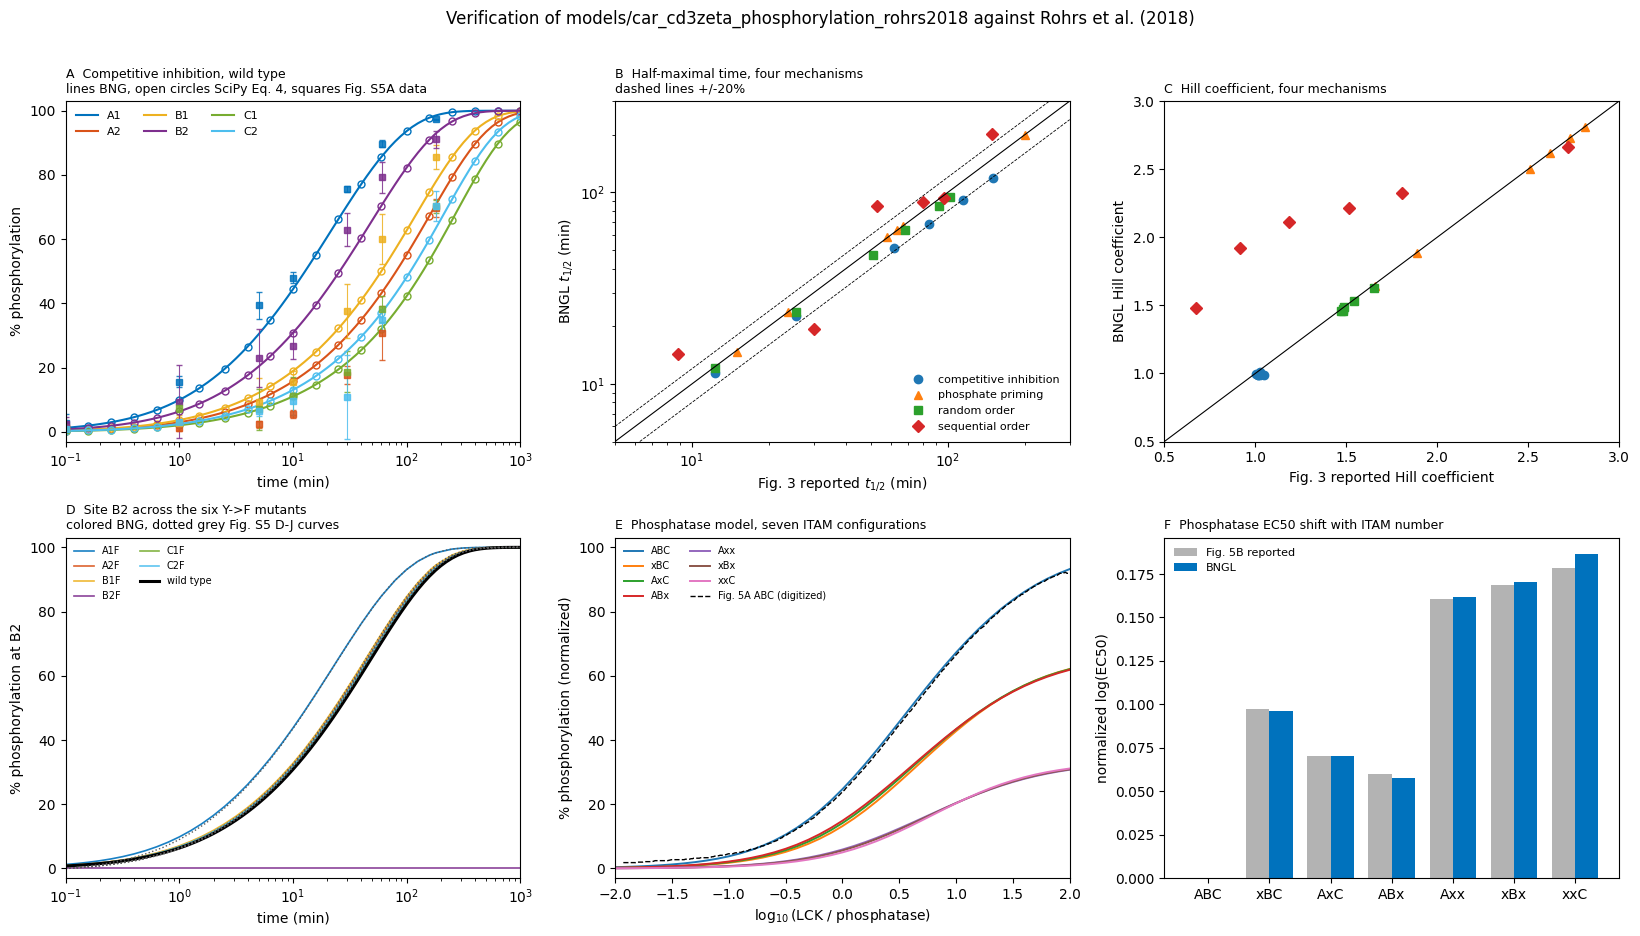

In [14]:
COLORS = {"A1": "#0072BD", "A2": "#D95319", "B1": "#EDB120",
          "B2": "#7E2F8E", "C1": "#77AC30", "C2": "#4DBEEE"}
fig, axes = plt.subplots(2, 3, figsize=(16.5, 9.5))

ax = axes[0, 0]
indep = solve_competitive(g.time.to_numpy())
for s in SITES:
    d = pd.read_csv(REF / "rohrs2018_figS5a_wildtype_10pct_pops_rep2_data_digitized.csv",
                    comment="#")
    ax.plot(g.time[g.time > 0], g["pct_" + s][g.time > 0], "-", lw=1.5, color=COLORS[s],
            label=s)
    ax.plot(g.time[g.time > 0][::4], (100 * indep[s] / CD3Z_T)[g.time > 0][::4], "o",
            mfc="none", mec=COLORS[s], ms=5)
    ax.errorbar(d.time_min, d[s], yerr=d[s + "_SD"], fmt="s", ms=4, color=COLORS[s],
                capsize=2, lw=0.8, alpha=0.85)
ax.set_xscale("log")
ax.set_xlim(0.1, 1000)
ax.set_ylim(-3, 103)
ax.set_xlabel("time (min)")
ax.set_ylabel("% phosphorylation")
ax.set_title("A  Competitive inhibition, wild type\n"
             "lines BNG, open circles SciPy Eq. 4, squares Fig. S5A data",
             fontsize=9, loc="left")
ax.legend(ncol=3, fontsize=8, frameon=False)

ax = axes[0, 1]
MARK = {"competitive_inhibition": "o", "random_order": "s",
        "phosphate_priming": "^", "sequential_order": "D"}
for mech, sub in fig3_cmp.groupby("mechanism"):
    ax.plot(sub.t_half_paper, sub.t_half_model, MARK[mech], ms=6,
            label=mech.replace("_", " "))
lims = [5, 300]
ax.plot(lims, lims, "k-", lw=0.8)
ax.plot(lims, [0.8 * v for v in lims], "k--", lw=0.6)
ax.plot(lims, [1.2 * v for v in lims], "k--", lw=0.6)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*lims)
ax.set_ylim(*lims)
ax.set_xlabel("Fig. 3 reported $t_{1/2}$ (min)")
ax.set_ylabel("BNGL $t_{1/2}$ (min)")
ax.set_title("B  Half-maximal time, four mechanisms\ndashed lines +/-20%",
             fontsize=9, loc="left")
ax.legend(fontsize=8, frameon=False, loc="lower right")

ax = axes[0, 2]
for mech, sub in fig3_cmp.groupby("mechanism"):
    ax.plot(sub.hill_paper, sub.hill_model, MARK[mech], ms=6,
            label=mech.replace("_", " "))
ax.plot([0.5, 3], [0.5, 3], "k-", lw=0.8)
ax.set_xlim(0.5, 3)
ax.set_ylim(0.5, 3)
ax.set_xlabel("Fig. 3 reported Hill coefficient")
ax.set_ylabel("BNGL Hill coefficient")
ax.set_title("C  Hill coefficient, four mechanisms", fontsize=9, loc="left")

ax = axes[1, 0]
for tag, site in MUTANTS.items():
    gm = read_table(WORK / f"car_cd3zeta_phosphorylation_rohrs2018_mutants_ode_{tag}.gdat")
    gm = gm[gm.time > 0]
    ax.plot(gm.time, gm.pct_B2, "-", lw=1.2, color=COLORS[site], alpha=0.9,
            label=f"{tag}")
ax.plot(g.time[g.time > 0], g.pct_B2[g.time > 0], "k-", lw=2.2, label="wild type")
for tag, slug in [("A1F", "figS5d_mutant_A1"), ("A2F", "figS5h_mutant_A2"),
                  ("B1F", "figS5e_mutant_B1"), ("C1F", "figS5f_mutant_C1"),
                  ("C2F", "figS5j_mutant_C2")]:
    dm = pd.read_csv(REF / f"rohrs2018_{slug}_model_digitized.csv", comment="#")
    ax.plot(dm.time_min, dm.B2, ":", lw=1.0, color="0.35")
ax.set_xscale("log")
ax.set_xlim(0.1, 1000)
ax.set_ylim(-3, 103)
ax.set_xlabel("time (min)")
ax.set_ylabel("% phosphorylation at B2")
ax.set_title("D  Site B2 across the six Y->F mutants\n"
             "colored BNG, dotted grey Fig. S5 D-J curves", fontsize=9, loc="left")
ax.legend(ncol=2, fontsize=7, frameon=False)

ax = axes[1, 1]
for cfg in CFGS:
    x, y = scans[cfg]
    ax.plot(x, y, "-", lw=1.4, label=cfg)
ax.plot(wt.log10_lck_over_phosphatase, wt.ABC, "k--", lw=1.0,
        label="Fig. 5A ABC (digitized)")
ax.set_xlabel(r"$\log_{10}$(LCK / phosphatase)")
ax.set_ylabel("% phosphorylation (normalized)")
ax.set_xlim(-2, 2)
ax.set_ylim(-3, 103)
ax.set_title("E  Phosphatase model, seven ITAM configurations", fontsize=9, loc="left")
ax.legend(ncol=2, fontsize=7, frameon=False)

ax = axes[1, 2]
idx = np.arange(len(CFGS))
ax.bar(idx - 0.19, fig5_cmp.log_ec50_paper, width=0.38, label="Fig. 5B reported",
       color="0.7")
ax.bar(idx + 0.19, fig5_cmp.log_ec50_model, width=0.38, label="BNGL", color="#0072BD")
ax.set_xticks(idx)
ax.set_xticklabels(CFGS)
ax.set_ylabel("normalized log(EC50)")
ax.set_title("F  Phosphatase EC50 shift with ITAM number", fontsize=9, loc="left")
ax.legend(fontsize=8, frameon=False)

fig.suptitle("Verification of models/car_cd3zeta_phosphorylation_rohrs2018 "
             "against Rohrs et al. (2018)", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(HERE / "verify_rohrs2018.png", dpi=150)
plt.show()

## 5. Summary

| check | result |
|---|---|
| committed `reference/` output reproduced | all values within rating-3 tolerance |
| BNG vs independent SciPy, four mechanisms | <= 1e-3 percentage points |
| BNG vs independent SciPy, six Y->F mutants | <= 1e-4 percentage points |
| BNG vs independent SciPy, phosphatase scan | <= 1e-3 percentage points |
| site conservation, chain ordering, site independence | exact to solver tolerance |
| Fig. S5 A-J plotted model curves | <= 2 percentage points, 54 site-panels |
| Fig. S5 A-J measured points | same residual as the authors' own published fit |
| Fig. 3 summaries, priming and random order | <= 8% in $t_{1/2}$, <= 0.02 in Hill |
| Fig. 3 summaries, competitive inhibition | Hill <= 0.06; $t_{1/2}$ bars inconsistent with the paper's own curve |
| Fig. 3 summaries, sequential order | **not reproduced** from Data S1 (documented) |
| Fig. 5A wild-type response | <= 1.5 percentage points |
| Fig. 5B normalized log(EC50) | <= 0.03 log units |
| Fig. 5C Hill differences | <= 0.013 after a constant offset |

In [15]:
shutil.rmtree(WORK, ignore_errors=True)
print("done")

done
